In [1]:
import os
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import numpy as np
import pandas as pd

plt.rcParams['font.family'] = 'Times New Roman'
matplotlib.style.use('tableau-colorblind10') #seaborn-v0_8-whitegrid  tableau-colorblind10

In [2]:
len_cf = 101  # add 1 as CFs value starting from year_0
MYs = [2020, 2030, 2040, 2050] #, 2060, 2070]
ssps = ["119", "245", "585"]   #"126"
sp_col, my_col = [], []

#### under fixed_AGWPCO2 approach, a future CO2 itself no longer has GWP=1 

In [3]:
ghggass = ['CO2']

from collections import defaultdict
#  3-layer nested dict
cf_col_gas_allgas = defaultdict(lambda: defaultdict(dict))

for ghggas in ghggass: 
    cf_col_gas = []
    for sp in ssps:
        for MY in MYs:
            #print(f"read point GWP value for {ghggas} SSP {sp}, model year {MY}")
            filename = "agwp_dcf_gwp100_tstep1" + ghggas + "_ssp" + sp + "_fair_start1750MY" + str(MY) + ".xlsx"
            cf_file = os.path.join("../FaIR_dpCFs/output/metrics_2026-02-23/", filename)

            cf_agwp_df = pd.read_excel(cf_file, sheet_name = "agwp_pointvalue" + ghggas+ "_" + str(MY) ) 
            cf_agwp_pointvalue = cf_agwp_df[ghggas].values
            cf_col_gas.append(cf_agwp_pointvalue)
    
            cf_col_gas_allgas[ghggas][f'ssp{sp}'][str(MY)] = cf_agwp_pointvalue

In [4]:
cf_col_gas_allgas['CO2']['ssp119']['2030']

array([0.00000000e+00, 1.56126662e-15, 3.02686213e-15, 4.41424256e-15,
       5.73730450e-15, 7.00712148e-15, 8.23252768e-15, 9.42058073e-15,
       1.05769285e-14, 1.17061000e-14, 1.28117359e-14, 1.38967715e-14,
       1.49635814e-14, 1.60140945e-14, 1.70498856e-14, 1.80722470e-14,
       1.90822461e-14, 2.00807710e-14, 2.10685665e-14, 2.20462627e-14,
       2.30143975e-14, 2.39734350e-14, 2.49237799e-14, 2.58657883e-14,
       2.67997773e-14, 2.77260320e-14, 2.86448113e-14, 2.95563522e-14,
       3.04608739e-14, 3.13585803e-14, 3.22496626e-14, 3.31343011e-14,
       3.40126666e-14, 3.48849215e-14, 3.57512214e-14, 3.66117150e-14,
       3.74665455e-14, 3.83158508e-14, 3.91597639e-14, 3.99984134e-14,
       4.08319238e-14, 4.16604156e-14, 4.24840058e-14, 4.33028079e-14,
       4.41169319e-14, 4.49264849e-14, 4.57315709e-14, 4.65322910e-14,
       4.73287435e-14, 4.81210241e-14, 4.89092257e-14, 4.96934389e-14,
       5.04737517e-14, 5.12502498e-14, 5.20230166e-14, 5.27921333e-14,
      

for CO2, SSP119, the old approach consistently higher than the new one, and much higher diff% for the CO2 GWP than the CH4: 

- Maximum % difference ≈ 19.1%

- Average % difference ≈ 15.8%

In [5]:
agwp_co2 =  pd.read_excel('AGWP_CO2_fixed.xlsx' )
agwp_co2_TH101 = agwp_co2.iloc[:101]
#agwp_co2_TH101
agwp_co2_vals = agwp_co2_TH101['AGWP_CO2_fixed'].values[1:]  # shape (100,)
agwp_co2_vals.shape

(100,)

### AGWP[future CO2] / AGWP[2019 CO2] 

In [6]:
# Output dictionary to store GWP values
gwp_results = {}

for ghg in cf_col_gas_allgas:
    gwp_results[ghg] = {}
    for ssp in cf_col_gas_allgas[ghg]:
        gwp_results[ghg][ssp] = {}
        
        for MY in cf_col_gas_allgas[ghg][ssp]:
            arr = cf_col_gas_allgas[ghg][ssp][MY]

            arr_trimmed = arr[1:101]  # drops 0th element, keeps next 100

            # get GWP values (elementwise divide by CO2 AGWP)
            gwp_array = arr_trimmed / agwp_co2_vals

            # Store result
            gwp_results[ghg][ssp][MY] = gwp_array

In [7]:
gwp_results['CO2']['ssp119']['2030']

array([0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393,
       0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393,
       0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393,
       0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393,
       0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393,
       0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393,
       0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393,
       0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393,
       0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393,
       0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393,
       0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393,
       0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393,
       0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393,
       0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393,
       0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568

In [8]:
gwp_results['CO2']['ssp585']['2050']

array([0.77040733, 0.77040733, 0.77040733, 0.77040733, 0.77040733,
       0.77040733, 0.77040733, 0.77040733, 0.77040733, 0.77040733,
       0.77040733, 0.77040733, 0.77040733, 0.77040733, 0.77040733,
       0.77040733, 0.77040733, 0.77040733, 0.77040733, 0.77040733,
       0.77040733, 0.77040733, 0.77040733, 0.77040733, 0.77040733,
       0.77040733, 0.77040733, 0.77040733, 0.77040733, 0.77040733,
       0.77040733, 0.77040733, 0.77040733, 0.77040733, 0.77040733,
       0.77040733, 0.77040733, 0.77040733, 0.77040733, 0.77040733,
       0.77040733, 0.77040733, 0.77040733, 0.77040733, 0.77040733,
       0.77040733, 0.77040733, 0.77040733, 0.77040733, 0.77040733,
       0.77040733, 0.77040733, 0.77040733, 0.77040733, 0.77040733,
       0.77040733, 0.77040733, 0.77040733, 0.77040733, 0.77040733,
       0.77040733, 0.77040733, 0.77040733, 0.77040733, 0.77040733,
       0.77040733, 0.77040733, 0.77040733, 0.77040733, 0.77040733,
       0.77040733, 0.77040733, 0.77040733, 0.77040733, 0.77040

In [9]:
gwp_results['CO2']['ssp119']['2050']

array([0.94700348, 0.94700348, 0.94700348, 0.94700348, 0.94700348,
       0.94700348, 0.94700348, 0.94700348, 0.94700348, 0.94700348,
       0.94700348, 0.94700348, 0.94700348, 0.94700348, 0.94700348,
       0.94700348, 0.94700348, 0.94700348, 0.94700348, 0.94700348,
       0.94700348, 0.94700348, 0.94700348, 0.94700348, 0.94700348,
       0.94700348, 0.94700348, 0.94700348, 0.94700348, 0.94700348,
       0.94700348, 0.94700348, 0.94700348, 0.94700348, 0.94700348,
       0.94700348, 0.94700348, 0.94700348, 0.94700348, 0.94700348,
       0.94700348, 0.94700348, 0.94700348, 0.94700348, 0.94700348,
       0.94700348, 0.94700348, 0.94700348, 0.94700348, 0.94700348,
       0.94700348, 0.94700348, 0.94700348, 0.94700348, 0.94700348,
       0.94700348, 0.94700348, 0.94700348, 0.94700348, 0.94700348,
       0.94700348, 0.94700348, 0.94700348, 0.94700348, 0.94700348,
       0.94700348, 0.94700348, 0.94700348, 0.94700348, 0.94700348,
       0.94700348, 0.94700348, 0.94700348, 0.94700348, 0.94700

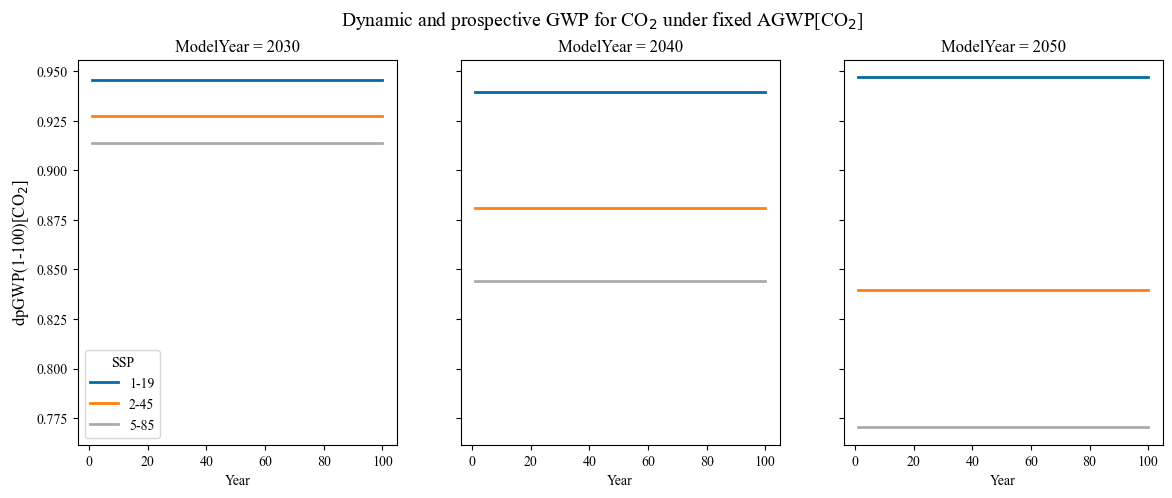

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
years = range(1, 101)

model_years = ['2030', '2040', '2050']
ssp_labels = {'ssp119': '1-19', 'ssp245': '2-45', 'ssp585': '5-85'}

for i, my in enumerate(model_years):
    ax = axes[i]

    # Plot each SSP line
    for ssp in ['ssp119', 'ssp245', 'ssp585']:
        gwp = gwp_results['CO2'][ssp][my]
        ax.plot(years, gwp, label=ssp_labels[ssp], linewidth=2)

    ax.set_title(f'ModelYear = {my}')
    ax.set_xlabel('Year')
    if i == 0:
        ax.set_ylabel(r'dpGWP(1-100)[CO$_2$]', fontsize = 12 )
        ax.legend(title='SSP')  # Only add legend to the first subplot
        
    #ax.grid(True)
 
fig.suptitle(r'Dynamic and prospective GWP for CO$_2$ under fixed AGWP[CO$_2$]', fontsize=14)
handles, labels = axes[0].get_legend_handles_labels()


### we'll combine the new GWP[CO2] together with CH4/N2O in a new df and .nc 